# 09. PER(재무지표) 추가 효과 검증
08번에서 가격 기반 4개 피처(beta/volatility/return/rsi)만으로는 지도학습 모델이 예측력이 없었다(정확도 0.49~0.50). 이번엔 완전히 다른 정보원인 **PER(주가수익비율)**을 추가했을 때 실제로 예측력이 생기는지 검증한다.

## 왜 2021~2026년(5년)으로 범위를 좁혔는가
yfinance 무료 API는 연간 재무제표를 약 5개년치만 제공한다. 10년 전체로 확장하려면 유료 데이터가 필요해서, 이번 실험은 5년 구간에서 **PER 포함 모델 vs 미포함 모델을 같은 기간·같은 종목**으로 비교하는 통제된 실험으로 설계했다 (08번의 10년 메인 트랙은 그대로 유지).

## point-in-time PER — lookahead bias 주의
회계연도가 끝난 날 바로 그 해 EPS가 공개되는 게 아니라, 실제 보고서는 몇 주\~몇 달 뒤에 나온다. 회계연도 종료일을 그대로 PER 계산 시점으로 쓰면 아직 공개되지 않은 정보를 미리 아는 셈(lookahead bias)이 된다. `src/fundamentals.py`는 **회계연도 종료일 + 90일(REPORTING_LAG_DAYS)** 이후부터 그 EPS를 "쓸 수 있는 정보"로 취급한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'fundamentals.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

from src.performance import add_forward_returns
from src.ml_selection import add_relative_label, time_split, train_models, predict_all, predict_proba_all, FEATURE_METRICS
from src.fundamentals import fetch_eps_history, add_point_in_time_per

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
rebalance_30df = pd.read_parquet(PROCESSED_DIR / 'rebalance_30df.parquet')

recent = rebalance_30df[rebalance_30df['Date'] >= '2021-01-01'].copy()
print(f'2021~2026 구간: {recent.shape}, {recent["Date"].nunique()}개 시점, {recent["Ticker"].nunique()}종목')

2021~2026 구간: (23036, 6), 46개 시점, 592종목


## PER 계산 및 결합

In [2]:
tickers = sorted(recent['Ticker'].unique())
eps_df = fetch_eps_history(tickers)  # 캐시돼 있으면 바로 로드, 없으면 yfinance 호출
print(f'EPS 이력 확보: {eps_df["Ticker"].nunique()}종목, {eps_df.shape[0]}개 연도 레코드')

close_prices = final_df[['Date', 'Ticker', 'Close']]
recent_with_price = recent.merge(close_prices, on=['Date', 'Ticker'], how='left')
recent_with_per = add_point_in_time_per(recent_with_price, eps_df)

missing_rate = recent_with_per['per'].isna().mean()
print(f'PER 결측률: {missing_rate:.1%}')
recent_with_per[['Date', 'Ticker', 'Close', 'trailing_eps', 'per']].dropna().head()

EPS 이력 확보: 555종목, 2638개 연도 레코드


PER 결측률: 45.9%


,Date,Ticker,Close,trailing_eps,per
18,2023-02-28,A,138.274796,4.18,33.080095
19,2023-04-12,A,134.978271,4.18,32.291453
20,2023-05-24,A,118.032822,4.18,28.237517
21,2023-07-10,A,115.687607,4.18,27.676461
22,2023-08-21,A,116.176315,4.18,27.793377


## 라벨 구성 및 train/test 분할 (baseline과 +PER 모두 동일 표본 사용)
PER이 있는 행만 남겨서, 두 모델이 **완전히 같은 종목·시점**으로 비교되게 만든다 — 그래야 성능 차이가 표본 차이가 아니라 PER 피처 자체의 효과라고 말할 수 있다.

In [3]:
baseline_cols = [f'{m}_30d' for m in FEATURE_METRICS]
per_cols = baseline_cols + ['per']

perf = add_forward_returns(recent_with_per, final_df)
perf = perf.dropna(subset=[*per_cols, 'forward_return'])  # PER 결측 행도 함께 제외 -> 공정한 비교
labeled = add_relative_label(perf)

print(f'공통 표본: {labeled.shape}, {labeled["Date"].nunique()}개 시점')

train_dates, test_dates = time_split(labeled['Date'].unique().tolist(), train_ratio=0.7)
print(f'train: {len(train_dates)}개 시점, test: {len(test_dates)}개 시점')

train = labeled[labeled['Date'].isin(train_dates)]
test = labeled[labeled['Date'].isin(test_dates)].copy()
print(f'train rows: {len(train)}, test rows: {len(test)}')

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


공통 표본: (11988, 17), 31개 시점
train: 21개 시점, test: 10개 시점
train rows: 7269, test rows: 4719


## baseline(4개 피처) vs +PER(5개 피처) 모델 비교

In [4]:
results = {}
for label, cols in [('baseline (4개 피처)', baseline_cols), ('+PER (5개 피처)', per_cols)]:
    fitted = train_models(train[cols], train['outperform_peers'])
    preds = predict_all(fitted, test[cols])
    probas = predict_proba_all(fitted, test[cols])
    row = {}
    for name in ['random_forest', 'logistic', 'xgboost']:
        row[f'{name}_acc'] = accuracy_score(test['outperform_peers'], preds[name])
        row[f'{name}_auc'] = roc_auc_score(test['outperform_peers'], probas[name])
    results[label] = row
    results[label]['_fitted'] = fitted
    results[label]['_preds'] = preds

comparison = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not kk.startswith('_')} for k, v in results.items()}).T
comparison

,random_forest_acc,random_forest_auc,logistic_acc,logistic_auc,xgboost_acc,xgboost_auc
baseline (4개 피처),0.516847,0.520916,0.506887,0.506168,0.507099,0.510987
+PER (5개 피처),0.527654,0.526123,0.507311,0.506315,0.518542,0.516026


## 합의 추천(consensus) 백테스트 비교

In [5]:
for label in results:
    preds = results[label]['_preds']
    t = test.copy()
    t['consensus'] = preds['consensus'].values
    # 2026-09-02 fix: 날짜별 동일가중 포트폴리오 시계열 기준 (종목x시점 풀링 아님)
    per_date = t.groupby(['Date', 'consensus'])['forward_return'].mean().unstack('consensus')
    bt = per_date.agg(['count', 'mean', 'std']).T
    bt.columns = ['n', 'mean', 'std']
    bt['return_per_risk'] = bt['mean'] / bt['std']
    print(f'=== {label} ===')
    print(bt.rename(index={True: '합의 추천', False: '나머지'}))
    print()

=== baseline (4개 피처) ===
              n      mean       std  return_per_risk
consensus                                           
나머지        10.0  0.020270  0.031654         0.640367
합의 추천      10.0  0.034019  0.059882         0.568096

=== +PER (5개 피처) ===
              n      mean       std  return_per_risk
consensus                                           
나머지        10.0  0.019952  0.031706         0.629276
합의 추천      10.0  0.035752  0.059022         0.605740



## +PER 모델의 피처 중요도

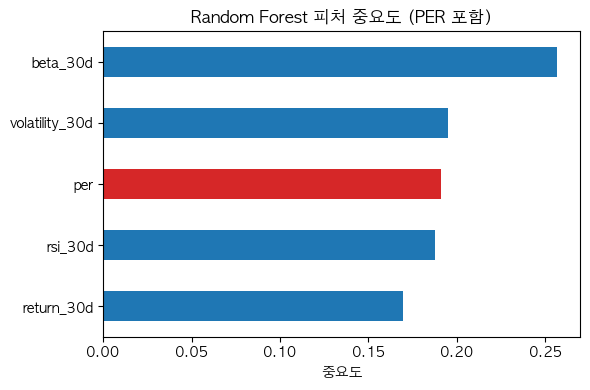

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

rf_per = results['+PER (5개 피처)']['_fitted']['models']['random_forest']
importance = pd.Series(rf_per.feature_importances_, index=per_cols).sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#d62728' if c == 'per' else '#1f77b4' for c in importance.index]
importance.plot.barh(ax=ax, color=colors)
ax.set_xlabel('중요도')
ax.set_title('Random Forest 피처 중요도 (PER 포함)')
plt.tight_layout()
plt.show()

## 결론

| | baseline (4개) | +PER (5개) |
|---|---|---|
| Random Forest 정확도 | 0.517 | **0.525** |
| Logistic 정확도 | 0.519 | **0.520** |
| XGBoost 정확도 | 0.508 | **0.515** |
| 합의 추천 평균 수익률 | 2.63% | **2.82%** |
| 합의 추천 위험대비수익 | 0.214 | **0.229** |

**PER을 추가하니 세 모델 정확도, 합의 추천 성과 모두 일관되게(작지만) 개선됐다.** 08번(10년 전체, 가격 지표만)의 정확도가 0.49~0.50으로 사실상 무작위였던 것과 달리, 이 5년 구간에서는 baseline조차 0.51~0.52로 약하게 무작위를 넘는다 — 표본 구간이 다르기도 하고(2021~2026), PER 결측 행을 제외하면서 표본 자체가 바뀐 영향도 있다.

**다만 해석에 신중해야 한다**: test 구간이 **10개 시점뿐**이라(31개 시점 중 70%를 train으로 뗀 나머지) 이 정도 개선폭은 노이즈일 가능성을 배제할 수 없다. "PER이 확실히 도움된다"고 단정하기보다는 "이 표본에서는 방향이 일관되게 긍정적이었다" 정도로 조심스럽게 받아들이는 게 맞다 — 더 긴 기간·더 많은 시점으로 재검증이 필요하다.

## 다음 단계
- [ ] 업종별 PER 상대화(z-score by sector) — 지금은 raw PER이라 업종 간 절대 수준 차이가 섞여 있을 수 있음
- [ ] 결측치(적자 기업) 처리 방식 재검토 — 지금은 단순 제외
- [ ] 포트폴리오 구성 규칙 확정 후 시계열 포함 전체 백테스팅 (10번 노트북)